# 训练代码

Train Epoch: 1 	 Loss: 2.305698
Epoch 1 time: 7.98 seconds
Test -- Average loss: 0.0008, Accuracy: 98.260

Train Epoch: 2 	 Loss: 0.009918
Epoch 2 time: 7.60 seconds
Test -- Average loss: 0.0005, Accuracy: 98.840

Train Epoch: 3 	 Loss: 0.011130
Epoch 3 time: 7.08 seconds
Test -- Average loss: 0.0006, Accuracy: 98.730

Total training time: 22.66 seconds
模型已保存到 cnn_model.pth


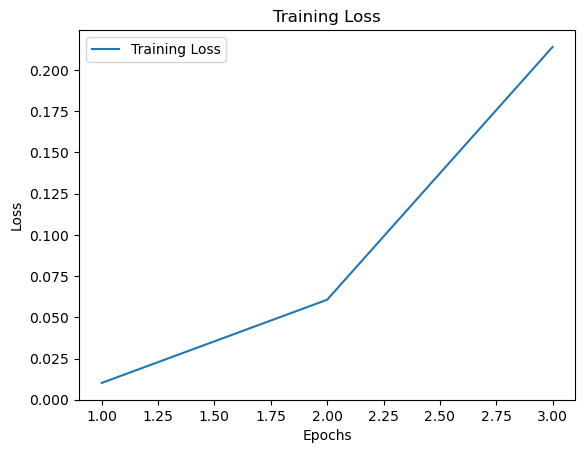

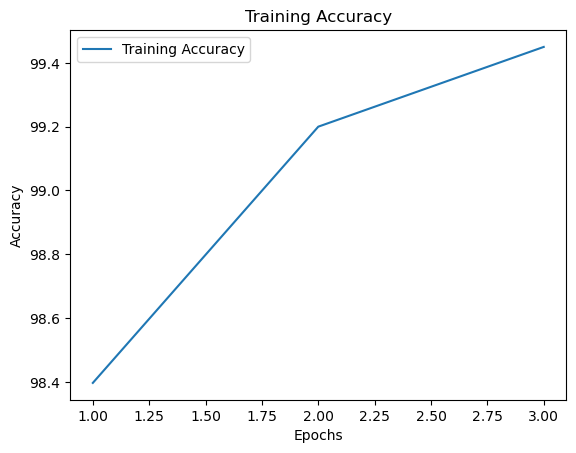

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time
import os

# 超参数
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 3

# 图像处理
pipeline = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
)

# 检查数据集是否已经存在
data_dir = ""
train_set_path = os.path.join(data_dir, "MNIST", "raw")
test_set_path = os.path.join(data_dir, "MNIST", "raw")

if not (os.path.exists(train_set_path) and os.path.exists(test_set_path)):
    # 下载并加载数据集
    train_set = datasets.MNIST(data_dir, train=True, download=True, transform=pipeline)
    test_set = datasets.MNIST(data_dir, train=False, download=True, transform=pipeline)
else:
    # 直接加载数据集
    train_set = datasets.MNIST(data_dir, train=True, download=False, transform=pipeline)
    test_set = datasets.MNIST(data_dir, train=False, download=False, transform=pipeline)

# 加载数据
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=True)

# 构建网络模型
class Digit(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 10, 5)
        self.conv2 = nn.Conv2d(10, 20, 3)
        self.fc1 = nn.Linear(20 * 10 * 10, 500)
        self.fc2 = nn.Linear(500, 10)

    def forward(self, x):
        input_size = x.size(0)
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2, 2)

        x = self.conv2(x)
        x = F.relu(x)

        x = x.view(input_size, -1)

        x = self.fc1(x)
        x = F.relu(x)

        x = self.fc2(x)

        output = F.log_softmax(x, dim=1)

        return output

# 优化器
model = Digit().to(DEVICE)
optimizer = optim.Adam(model.parameters())

# 训练方法
def train_model(model, device, train_loader, optimizer, epoch):
    model.train()
    train_losses = []
    train_accuracy = []
    start_time = time.time()
    for batch_index, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()
        if batch_index % 1000 == 0:
            print("Train Epoch: {} \t Loss: {:.6f}".format(epoch, loss.item()))

    # 计算准确率
    model.eval()
    correct = 0.0
    with torch.no_grad():
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.max(1, keepdim=True)[1]
            correct += pred.eq(target.view_as(pred)).sum().item()
    accuracy = 100.0 * correct / len(train_loader.dataset)
    train_accuracy.append(accuracy)

    train_losses.append(loss.item())
    end_time = time.time()
    epoch_time = end_time - start_time

    return train_losses, train_accuracy, epoch_time

# 测试方法
def test_model(model, device, test_loader):
    model.eval()
    correct = 0.0
    test_loss = 0.0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.cross_entropy(output, target).item()
            pred = output.max(1, keepdim=True)[1]
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_loader.dataset)
    print(
        "Test -- Average loss: {:.4f}, Accuracy: {:.3f}\n".format(
            test_loss, 100.0 * correct / len(test_loader.dataset)
        )
    )

# 调用
train_losses = []
train_accuracy = []
total_time = 0.0
for epoch in range(1, EPOCHS + 1):
    losses, accuracy, epoch_time = train_model(model, DEVICE, train_loader, optimizer, epoch)
    train_losses.extend(losses)
    train_accuracy.extend(accuracy)
    total_time += epoch_time
    print("Epoch {} time: {:.2f} seconds".format(epoch, epoch_time))
    test_model(model, DEVICE, test_loader)

print("Total training time: {:.2f} seconds".format(total_time))

# 保存模型
model_path = "cnn_model.pth"
torch.save(model.state_dict(), model_path)
print(f"模型已保存到 {model_path}")

# 绘制损失曲线
plt.plot(range(1, EPOCHS + 1), train_losses, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

# 绘制准确率曲线
plt.plot(range(1, EPOCHS + 1), train_accuracy, label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()
plt.show()

# 测试代码与界面

In [ ]:
import os
import csv
import tkinter as tk
from tkinter import filedialog, messagebox
from tkinter import ttk
from PIL import Image, ImageOps, ImageTk
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms

# 定义 CNN 模型（适用于 MNIST 单个数字识别）
class Digit(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=3)
        self.fc1   = nn.Linear(20 * 10 * 10, 500)
        self.fc2   = nn.Linear(500, 10)

    def forward(self, x):
        input_size = x.size(0)
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        x = F.relu(self.conv2(x))
        x = x.view(input_size, -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

# 加载模型
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Digit().to(DEVICE)
model_path = "cnn_model.pth"
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()
else:
    raise FileNotFoundError(f"模型文件 {model_path} 不存在，请确保模型已保存")

# 定义转换管道（保证图片转换为 28x28 灰度图）
transform_pipeline = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 定义 Tkinter 应用
class DigitRecognizerApp:
    def __init__(self, master):
        self.master = master
        self.master.title("基于CNN算法的手写数字识别系统")
        self.master.geometry("800x600")
        self.master.configure(bg="#f2f2f2")

        style = ttk.Style()
        style.configure("TButton", font=("Helvetica", 12), padding=6)
        style.configure("TLabel", font=("Helvetica", 12))

        # 标题
        title = tk.Label(master, text="基于CNN算法的手写数字识别系统", font=("Helvetica", 24, "bold"),
                         bg="#f2f2f2", fg="#333333")
        title.pack(pady=10)

        # 单张图片识别区域
        single_frame = tk.Frame(master, bg="#e6f2ff", bd=2, relief="groove")
        single_frame.pack(padx=20, pady=10, fill="x")

        s_label = tk.Label(single_frame, text="单张图片识别", font=("Helvetica", 18, "bold"),
                           bg="#e6f2ff", fg="#003366")
        s_label.pack(pady=5)

        self.single_image_label = tk.Label(single_frame, bg="#ffffff")
        self.single_image_label.pack(pady=5)

        btn_frame = tk.Frame(single_frame, bg="#e6f2ff")
        btn_frame.pack(pady=5)
        self.upload_single_btn = ttk.Button(btn_frame, text="上传图片", command=self.upload_single_image)
        self.upload_single_btn.grid(row=0, column=0, padx=10)
        self.predict_single_btn = ttk.Button(btn_frame, text="识别数字", command=self.predict_single_digit)
        self.predict_single_btn.grid(row=0, column=1, padx=10)

        self.single_result_label = tk.Label(single_frame, text="", font=("Helvetica", 16),
                                            bg="#e6f2ff", fg="#006600")
        self.single_result_label.pack(pady=5)

        # 多张图片识别区域
        multi_frame = tk.Frame(master, bg="#ffe6e6", bd=2, relief="groove")
        multi_frame.pack(padx=20, pady=10, fill="both", expand=True)

        m_label = tk.Label(multi_frame, text="多张图片识别", font=("Helvetica", 18, "bold"),
                           bg="#ffe6e6", fg="#990000")
        m_label.pack(pady=5)

        multi_btn_frame = tk.Frame(multi_frame, bg="#ffe6e6")
        multi_btn_frame.pack(pady=5)
        self.upload_multi_btn = ttk.Button(multi_btn_frame, text="上传多张图片", command=self.upload_multi_images)
        self.upload_multi_btn.grid(row=0, column=0, padx=10)
        self.predict_multi_btn = ttk.Button(multi_btn_frame, text="批量识别", command=self.predict_multi_digits)
        self.predict_multi_btn.grid(row=0, column=1, padx=10)
        self.save_csv_btn = ttk.Button(multi_btn_frame, text="保存 CSV", command=self.save_results_to_csv)
        self.save_csv_btn.grid(row=0, column=2, padx=10)

        # 显示多图片识别结果（使用列表框）
        self.result_listbox = tk.Listbox(multi_frame, font=("Helvetica", 14), bg="#fff", fg="#333")
        self.result_listbox.pack(pady=5, padx=20, fill="both", expand=True)

        # 底部版权信息
        footer = tk.Label(master, text="© 2025 单一数字识别系统", font=("Helvetica", 10),
                          bg="#f2f2f2", fg="#666666")
        footer.pack(side="bottom", pady=10)

        # 用于保存单张和多张图片
        self.single_image = None
        self.multi_images = []  # 存储 (PIL Image, 文件名) 元组

        # 用于存储多图预测结果，格式为 [(文件名, 预测结果), ...]
        self.multi_predictions = []

    def upload_single_image(self):
        try:
            file_path = filedialog.askopenfilename(
                filetypes=[("Image files", "*.png;*.jpg;*.jpeg"), ("All files", "*.*")]
            )
            if not file_path:
                return
            file_path = os.path.abspath(file_path)
            img = Image.open(file_path)
            img = ImageOps.grayscale(img)
            img.thumbnail((200, 200))
            self.single_image = img
            img_tk = ImageTk.PhotoImage(img)
            self.single_image_label.config(image=img_tk)
            self.single_image_label.image = img_tk
            self.single_result_label.config(text="")
        except Exception as e:
            messagebox.showerror("错误", f"无法加载图片: {e}")

    def predict_single_digit(self):
        if self.single_image is None:
            messagebox.showinfo("提示", "请先上传单张图片")
            return
        try:
            img_tensor = transform_pipeline(self.single_image).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                output = model(img_tensor)
                predicted_digit = torch.argmax(output, dim=1).item()
            self.single_result_label.config(text=f"识别结果： {predicted_digit}")
        except Exception as e:
            messagebox.showerror("错误", f"识别过程中出错: {e}")

    def upload_multi_images(self):
        try:
            file_paths = filedialog.askopenfilenames(
                filetypes=[("Image files", "*.png;*.jpg;*.jpeg"), ("All files", "*.*")]
            )
            if not file_paths:
                return
            # 清空之前的多图数据和显示结果
            self.multi_images.clear()
            self.result_listbox.delete(0, tk.END)
            self.multi_predictions.clear()
            for f in file_paths:
                f = os.path.abspath(f)
                img = Image.open(f)
                img = ImageOps.grayscale(img)
                # 制作缩略图用于显示
                img_disp = img.copy()
                img_disp.thumbnail((100, 100))
                self.multi_images.append((img, os.path.basename(f)))
                self.result_listbox.insert(tk.END, f"待识别： {os.path.basename(f)}")
        except Exception as e:
            messagebox.showerror("错误", f"无法加载图片: {e}")

    def predict_multi_digits(self):
        if not self.multi_images:
            messagebox.showinfo("提示", "请先上传多张图片")
            return
        self.result_listbox.delete(0, tk.END)
        self.multi_predictions.clear()
        for img, fname in self.multi_images:
            try:
                img_tensor = transform_pipeline(img).unsqueeze(0).to(DEVICE)
                with torch.no_grad():
                    output = model(img_tensor)
                    pred = torch.argmax(output, dim=1).item()
                self.multi_predictions.append((fname, pred))
                self.result_listbox.insert(tk.END, f"{fname} 识别结果： {pred}")
            except Exception as e:
                self.result_listbox.insert(tk.END, f"{fname} 识别出错")
                print(f"{fname} error: {e}")

    def save_results_to_csv(self):
        if not self.multi_predictions:
            messagebox.showinfo("提示", "请先批量识别获得结果")
            return
        try:
            csv_path = filedialog.asksaveasfilename(defaultextension=".csv",
                                                    filetypes=[("CSV files", "*.csv"), ("All files", "*.*")],
                                                    title="保存预测结果")
            if not csv_path:
                return
            with open(csv_path, mode="w", newline="") as csv_file:
                writer = csv.writer(csv_file)
                writer.writerow(["图像文件", "预测结果"])
                for fname, pred in self.multi_predictions:
                    writer.writerow([fname, pred])
            messagebox.showinfo("提示", f"预测结果已保存到 {csv_path}")
        except Exception as e:
            messagebox.showerror("错误", f"保存 CSV 文件时出错: {e}")

if __name__ == "__main__":
    root = tk.Tk()
    app = DigitRecognizerApp(root)
    root.mainloop()

/tmp/ipykernel_72870/877919687.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=DEVICE))
